                X_train (784 pixels)
                          |
                          v
        -----------------------------------
        |  Logistic Regression (GridSearch)|
        -----------------------------------
                          |
                 Best Model Found
                          |
        -----------------------------------
        |                                 |
        v                                 v

  OOF Predictions                 Final Trained Model
 (cross_val_predict)                    (fit full data)
        |                                 |
        v                                 v

 meta_train[:, digit]         test probabilities (meta_test)

        |                                 |
        ----------- STACKING -------------
                          |
                          v

                Meta Logistic Regression
                          |
                          v

                   FINAL DIGIT

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
print("Loading MNIST...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

Loading MNIST...


In [5]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [6]:
y

array([5, 0, 4, ..., 4, 5, 6])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_test_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
# param_grid = {
#     'C': [0.1, 1, 10],
#     'solver': ['liblinear'],
#     'max_iter': [500]
# }
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'max_iter': [1000],
    'penalty': ['l2']
}

In [72]:
n_classes = 10

meta_train = np.zeros(
    (X_train_scaled.shape[0], n_classes)
)

meta_test = np.zeros(
    (X_test_scaled.shape[0], n_classes)
)

best_models = {}
best_params = {}

In [73]:
outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for digit in range(10):

    print("\n" + "="*60)
    print(f"Training model for Digit {digit} vs Rest")
    print("="*60)

    y_binary = (y_train == digit).astype(int)

    # Hyperparameter tuning
    grid = GridSearchCV(
        LogisticRegression(),
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=3
    )

    grid.fit(X_train_scaled, y_binary)

    best_model = grid.best_estimator_

    best_models[digit] = best_model
    best_params[digit] = grid.best_params_

    print("Best Params:", grid.best_params_)

     
    # OOF Predictions (for stacking)
    oof_probs = cross_val_predict(
        best_model,
        X_train_scaled,
        y_binary,
        cv=outer_cv,
        method="predict_proba",
        n_jobs=3
    )[:, 1]

    meta_train[:, digit] = oof_probs

    # Train final model
    best_model.fit(X_train_scaled, y_binary)

    # Binary accuracy
    y_train_pred = best_model.predict(X_train_scaled)

    binary_acc = accuracy_score(y_binary, y_train_pred)

    print("Binary Accuracy:", binary_acc)
    # Test probabilities
    test_probs = best_model.predict_proba(X_test_scaled)[:, 1]
    meta_test[:, digit] = test_probs


Training model for Digit 0 vs Rest
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Binary Accuracy: 0.9938571428571429

Training model for Digit 1 vs Rest
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Binary Accuracy: 0.9935892857142857

Training model for Digit 2 vs Rest
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Binary Accuracy: 0.9819464285714286

Training model for Digit 3 vs Rest
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Binary Accuracy: 0.9778571428571429

Training model for Digit 4 vs Rest
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Binary Accuracy: 0.9864821428571429

Training model for Digit 5 vs Rest
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Binary Accuracy: 0.97875

Training model for Digit 6 vs Rest
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty'

Exception ignored in: <function ResourceTracker.__del__ at 0x1055c1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102dadc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105319c60>
Traceback (most recent call last

In [74]:
print("Meta train shape:", meta_train.shape)
print("Meta test shape:", meta_test.shape)

Meta train shape: (56000, 10)
Meta test shape: (14000, 10)


In [75]:
meta_model = LogisticRegression(
    
    max_iter=1000
)

meta_model.fit(meta_train, y_train)

LogisticRegression(max_iter=1000)

In [76]:
y_pred = meta_model.predict(meta_test)

In [77]:
y_pred

array([7, 3, 1, ..., 6, 2, 8])

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9166428571428571


In [133]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.96      0.97      0.96      1575
           2       0.93      0.89      0.91      1398
           3       0.90      0.88      0.89      1428
           4       0.93      0.92      0.92      1365
           5       0.89      0.86      0.87      1263
           6       0.95      0.95      0.95      1375
           7       0.93      0.93      0.93      1459
           8       0.83      0.90      0.86      1365
           9       0.89      0.88      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



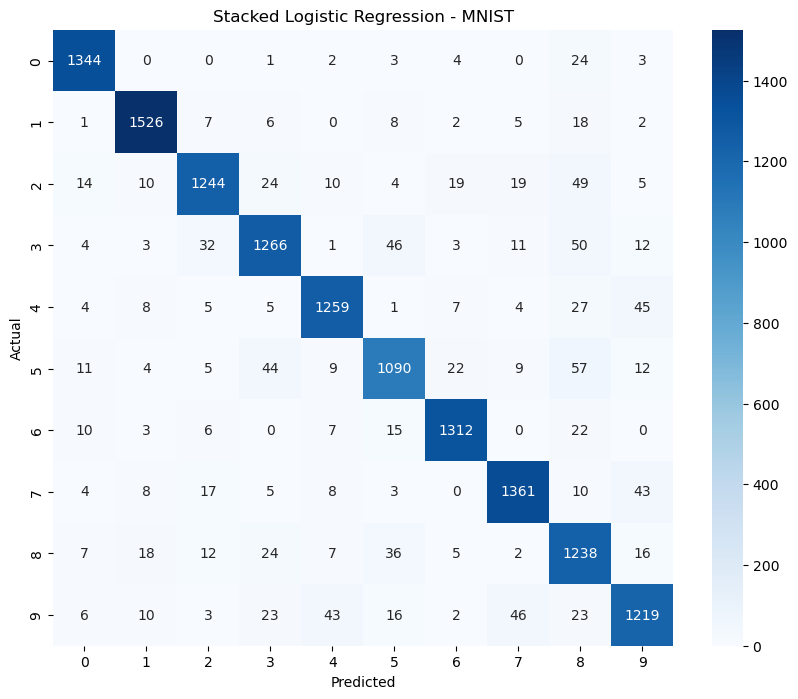

In [65]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Stacked Logistic Regression - MNIST")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [79]:
for i in range(10):
    print(f"Image {i} → Predicted Digit: {y_pred[i]}")

Image 0 → Predicted Digit: 7
Image 1 → Predicted Digit: 3
Image 2 → Predicted Digit: 1
Image 3 → Predicted Digit: 1
Image 4 → Predicted Digit: 2
Image 5 → Predicted Digit: 5
Image 6 → Predicted Digit: 9
Image 7 → Predicted Digit: 3
Image 8 → Predicted Digit: 8
Image 9 → Predicted Digit: 1


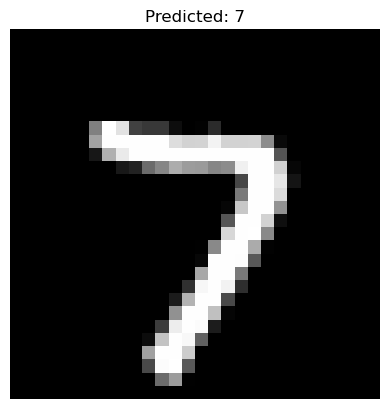

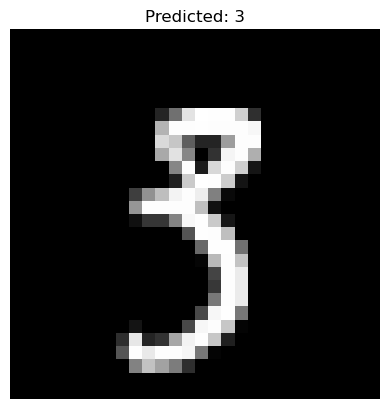

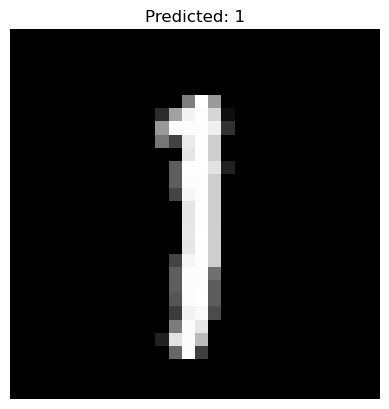

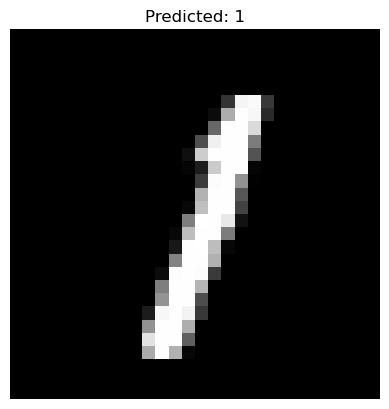

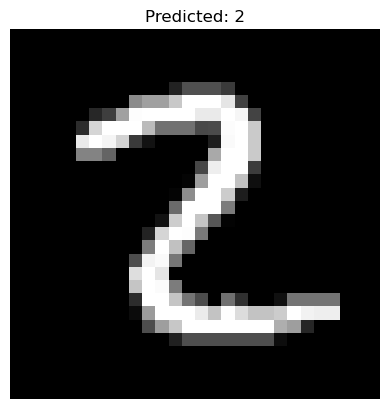

In [80]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis("off")
    plt.show()

In [139]:
import numpy as np

def predict_digit_with_confidence(
    image_28x28,
    scaler,
    best_models,
    meta_model
):
    """
    Predict digit and confidence using stacked model.
    """

    # Flatten image
    x = image_28x28.reshape(1, -1).astype(np.float32)
   
     
    # Scale
    x_scaled = scaler.transform(x)

    # Generate meta-features
    meta_features = np.zeros((1, 10))

    for digit in range(10):
        prob = best_models[digit].predict_proba(x_scaled)[0, 1]
        meta_features[0, digit] = prob

    # Final prediction probabilities
    class_probs = meta_model.predict_proba(meta_features)[0]

    predicted_digit = np.argmax(class_probs)
    confidence = class_probs[predicted_digit]


    return {
        "digit": int(predicted_digit),
        "confidence": float(confidence),
        "all_probabilities": class_probs
    }

In [140]:
from PIL import Image
import numpy as np

def predict_digit_from_file(
    image_path,
    scaler,
    best_models,
    meta_model
):
    img = Image.open(image_path).convert("L")

    img = img.resize((28, 28))

    img_array = np.array(img)

    # Optional: invert colors if digit is black on white background
    img_array = 255 - img_array

    plt.figure(figsize=(3, 3))
    plt.imshow(img_array, cmap="gray")
    plt.title("Model Input (After Inversion)")
    plt.axis("off")
    plt.show()

    pred = predict_digit_with_confidence(
        img_array,
        scaler,
        best_models,
        meta_model
    )

    return pred

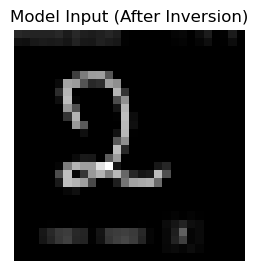

Predicted Digit: {'digit': 5, 'confidence': 0.9326724421231483, 'all_probabilities': array([3.10950197e-03, 2.16421822e-05, 2.94430761e-04, 3.58298185e-02,
       2.03204282e-07, 9.32672442e-01, 2.78855903e-02, 1.81834888e-04,
       2.27003137e-06, 2.26605507e-06])}


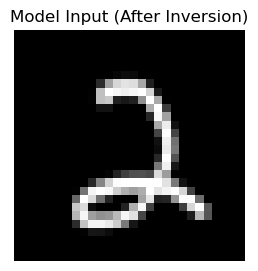

Predicted Digit: {'digit': 2, 'confidence': 0.9612426260811555, 'all_probabilities': array([1.07352740e-03, 2.20097691e-03, 9.61242626e-01, 1.64109549e-02,
       6.27578022e-04, 8.51381712e-03, 6.14675544e-03, 2.99989691e-03,
       6.51608864e-04, 1.32258375e-04])}


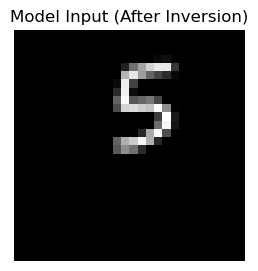

Predicted Digit: {'digit': 3, 'confidence': 0.26356531317934706, 'all_probabilities': array([0.01762049, 0.05633872, 0.14075711, 0.26356531, 0.03651368,
       0.07726667, 0.02186854, 0.12153696, 0.13533376, 0.12919876])}


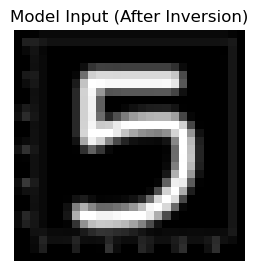

Predicted Digit: {'digit': 7, 'confidence': 0.780117061757787, 'all_probabilities': array([1.21389421e-02, 9.11442824e-02, 2.83201379e-02, 2.77864004e-02,
       1.29658635e-02, 3.70122989e-02, 8.01479107e-03, 7.80117062e-01,
       5.98512452e-05, 2.44037061e-03])}


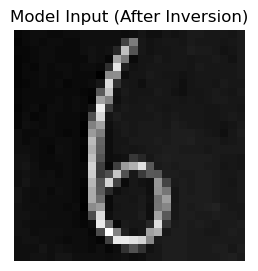

Predicted Digit: {'digit': 5, 'confidence': 0.7405199023547955, 'all_probabilities': array([2.15201985e-03, 1.81321537e-01, 1.80633668e-03, 7.45469887e-03,
       7.23853439e-04, 7.40519902e-01, 6.50325615e-03, 5.93974030e-02,
       5.48341462e-06, 1.15509008e-04])}


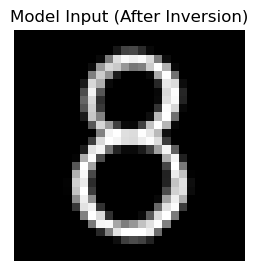

Predicted Digit: {'digit': 3, 'confidence': 0.8625000822173532, 'all_probabilities': array([0.0020781 , 0.00228779, 0.01802788, 0.86250008, 0.00391126,
       0.03410751, 0.00112794, 0.00431866, 0.03712993, 0.03451084])}


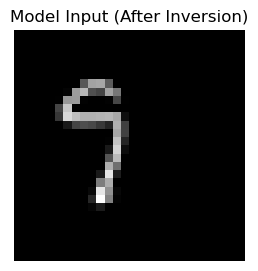

Predicted Digit: {'digit': 5, 'confidence': 0.9771946499398998, 'all_probabilities': array([1.49718971e-03, 9.12255968e-04, 7.18512002e-04, 5.47485591e-03,
       1.78556180e-04, 9.77194650e-01, 1.02026586e-02, 6.49578343e-04,
       2.43054694e-03, 7.41196460e-04])}


In [141]:
# Black to white

image_array = [
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/two.png", 
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/two2.png", 
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/five.png",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/five2.png",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/six.jpeg",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/eight.png",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/nine.jpg",
]

for img in image_array:
    pred = predict_digit_from_file(img,
    scaler,
    best_models,
    meta_model
    ) 
    print("Predicted Digit:", pred)

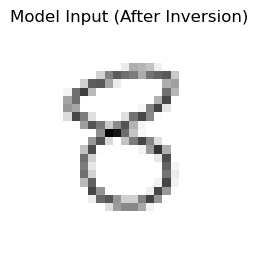

Predicted Digit: {'digit': 5, 'confidence': 0.7405199023547948, 'all_probabilities': array([2.15201985e-03, 1.81321537e-01, 1.80633668e-03, 7.45469887e-03,
       7.23853439e-04, 7.40519902e-01, 6.50325615e-03, 5.93974030e-02,
       5.48341462e-06, 1.15509008e-04])}


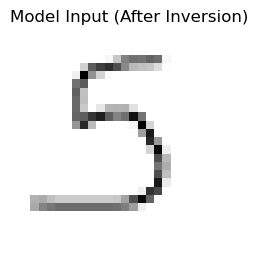

Predicted Digit: {'digit': 5, 'confidence': 0.7405199023547948, 'all_probabilities': array([2.15201985e-03, 1.81321537e-01, 1.80633668e-03, 7.45469887e-03,
       7.23853439e-04, 7.40519902e-01, 6.50325615e-03, 5.93974030e-02,
       5.48341462e-06, 1.15509008e-04])}


In [138]:
#minst_data

image_array = [
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/blk_background/eight.jpg",
               "/Users/gazifayazwani/Desktop/ML/MNIST/images/blk_background/five.jpg"
]

for img in image_array:
    pred = predict_digit_from_file(img,
    scaler,
    best_models,
    meta_model
    ) 
    print("Predicted Digit:", pred)